In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


In [ ]:
df=pd.read_csv("loan_approval_data.csv")
df.head()

In [ ]:
df.info()

In [ ]:
df.describe()

HANDLE MISSING VALUES

In [ ]:
categorical_cols= df.select_dtypes(include=["object"]).columns
numerical_cols= df.select_dtypes(include=["number"]).columns

In [ ]:
categorical_cols

In [ ]:
numerical_cols

In [ ]:
from sklearn.impute import SimpleImputer

num_imp=SimpleImputer(strategy="mean")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])

In [ ]:
df

In [ ]:
cat_imp=SimpleImputer(strategy="most_frequent")
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])

In [ ]:
df.isnull().sum()

EDA EXPLORATORY DATA ANALYSIS

In [ ]:
# HWO BALANCED OUR CLASSES ARE
classes_count=df["Loan_Approved"].value_counts()
plt.pie(classes_count,labels=["No","Yes"],autopct="%1.1f%%")
plt.title("is loan approved or not")

In [ ]:
#ANALYSE CATEGORIES
# gender_cnt=df["Gender"].value_counts()
# ax=sns.barplot(gender_cnt)
# ax.bar_label(ax.containers[0])

edu_cnt=df["Education_Level"].value_counts()
ax=sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

In [ ]:
#analyse income
sns.histplot(df["Applicant_Income"],
             bins=20
             )

In [ ]:
sns.histplot(df["Coapplicant_Income"],
             bins=20
             )

In [ ]:
#outliers- box plots
sns.boxplot(data=df,
            x="Loan_Approved",
            y="Applicant_Income"

            )

In [ ]:
fig,axes=plt.subplots(2,3)
sns.boxplot(ax=axes[0,0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[0,2],data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,0],data=df,x="Loan_Approved",y="Savings")
sns.boxplot(ax=axes[1,1],data=df,x="Loan_Approved",y="Age")
sns.boxplot(ax=axes[1,2],data=df,x="Loan_Approved",y="Loan_Amount")

plt.tight_layout()



In [ ]:
#relation of credit score and loan approval
sns.histplot(data=df,
             hue="Loan_Approved",
             x="Credit_Score",
             bins=20,
             multiple="dodge"
             )

In [ ]:
sns.histplot(data=df,
             hue="Loan_Approved",
             x="Applicant_Income",
             bins=20,
             multiple="dodge"
             )

In [ ]:
#   Remove Applicant ID
df.drop(columns="Applicant_ID")

FEATURE ENCODING

In [ ]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
df.columns
df.info()

In [ ]:
#for label encoder
le=LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])

#for one hot encoding

cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]
ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded=ohe.fit_transform(df[cols])
encoded_df=pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols),index=df.index)

In [ ]:
encoded

In [ ]:
ohe.get_feature_names_out(cols)

In [75]:
encoded_df.head()

,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [79]:
df=pd.concat([df.drop(columns=cols),encoded_df],axis=1)

In [80]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2.0,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,3.0,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,4.0,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_ID                     1000 non-null   float64
 1   Applicant_Income                 1000 non-null   float64
 2   Coapplicant_Income               1000 non-null   float64
 3   Age                              1000 non-null   float64
 4   Dependents                       1000 non-null   float64
 5   Credit_Score                     1000 non-null   float64
 6   Existing_Loans                   1000 non-null   float64
 7   DTI_Ratio                        1000 non-null   float64
 8   Savings                          1000 non-null   float64
 9   Collateral_Value                 1000 non-null   float64
 10  Loan_Amount                      1000 non-null   float64
 11  Loan_Term                        1000 non-null   float64
 12  Education_Level      

CORRELATION HEATMAP

In [83]:
nums_cols=df.select_dtypes(include="number")
corr_matrix=nums_cols.corr()

In [84]:
corr_matrix

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
Applicant_ID,1.000000,0.020970,0.041140,0.014579,0.012495,-0.028170,0.024995,0.000174,0.022692,0.031759,...,0.005426,-0.039878,0.019178,0.012969,-0.030187,0.036067,0.005906,-0.074056,0.022803,0.038417
Applicant_Income,0.020970,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,...,0.032794,0.074209,-0.031234,0.004845,-0.036260,-0.020871,-0.025011,0.102589,-0.044639,-0.011995
Coapplicant_Income,0.041140,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,...,0.028000,0.016022,0.059549,-0.010058,0.030045,-0.010148,-0.001146,0.037640,0.004312,-0.047929
Age,0.014579,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,...,-0.006283,0.029865,0.037293,0.003100,-0.025661,0.048402,-0.066041,0.021232,-0.012960,0.072462
Dependents,0.012495,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,...,-0.044642,0.027343,-0.005785,-0.032278,0.024082,0.013706,-0.009250,-0.018757,0.030197,-0.054147
Credit_Score,-0.028170,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,...,0.026013,-0.008658,0.015324,-0.006946,0.004445,-0.039739,-0.007076,0.066736,-0.000049,-0.046087
Existing_Loans,0.024995,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,...,-0.010035,0.001777,0.023212,-0.053971,0.035629,-0.038762,-0.009642,0.030520,-0.019306,0.045391
DTI_Ratio,0.000174,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,...,0.040432,-0.014125,-0.036648,0.044898,-0.006156,0.009624,-0.007214,0.002090,-0.003506,0.026018
Savings,0.022692,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,...,0.032558,-0.012217,-0.028948,0.005438,0.016833,-0.006667,-0.011683,0.004381,-0.030208,0.027178
Collateral_Value,0.031759,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,...,0.040406,-0.050975,-0.007120,0.020061,0.007975,0.000897,0.035760,-0.013464,-0.014480,-0.009655


In [85]:
nums_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Applicant_ID                      -0.011167
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed    

<Axes: >

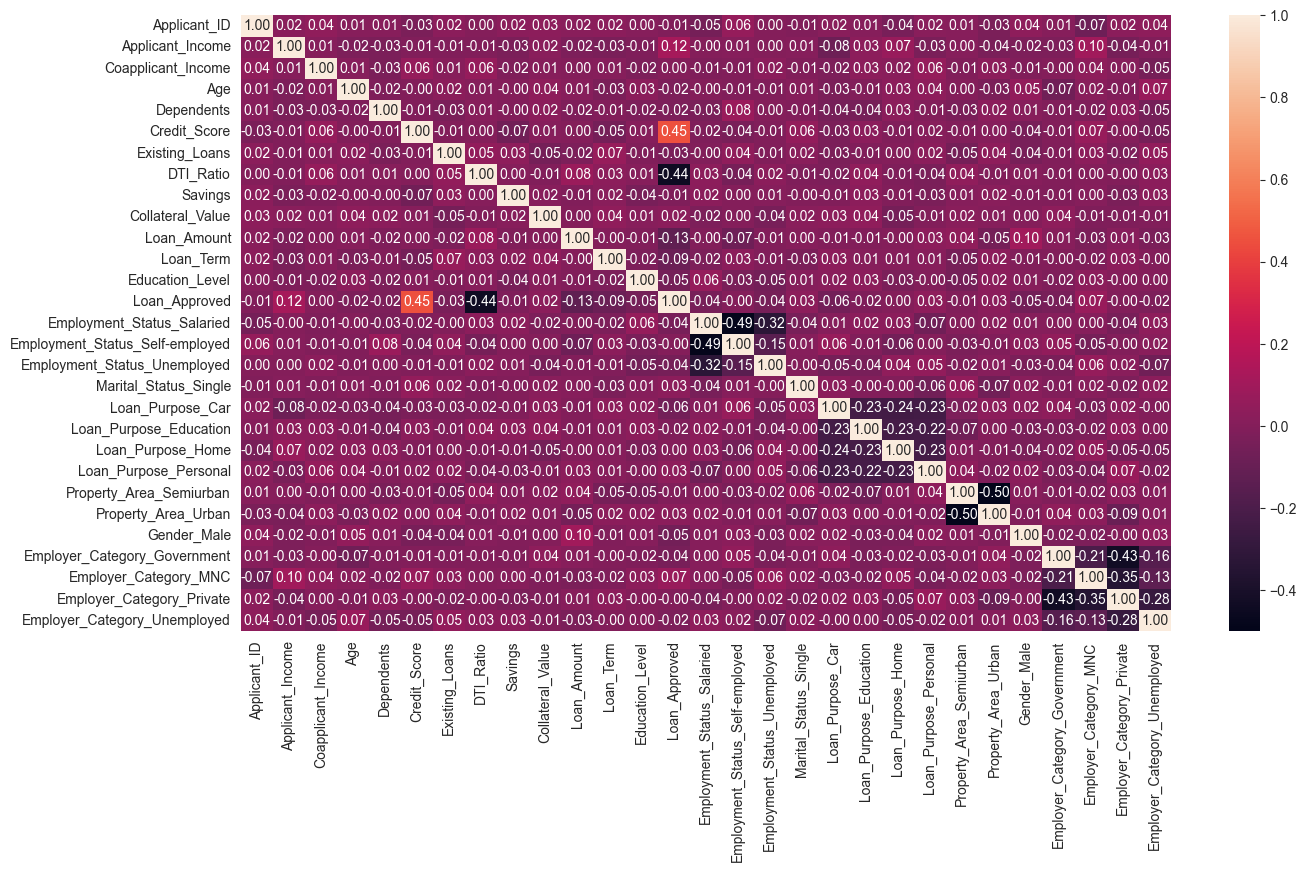

In [88]:
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f"
)

TRAIN TEST SPLIT + FEATURE SCALING

In [90]:
X=df.drop(columns="Loan_Approved")
y=df["Loan_Approved"]
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [91]:
X_train.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
29,30.0,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
535,536.0,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
695,696.0,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
557,558.0,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
836,837.0,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [93]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

TRAIN AND EVALUATE MODEL

In [101]:
#LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression()

log_model.fit(X_train_scaled,y_train)
y_pred=log_model.predict(X_test_scaled)

#EVALUATION
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
print("precision:",precision_score(y_test,y_pred))
print("recall:",recall_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("c-matrix","\n",confusion_matrix(y_test,y_pred))

precision: 0.7868852459016393
recall: 0.7868852459016393
accuracy: 0.87
f1: 0.7868852459016393
c-matrix 
 [[126  13]
 [ 13  48]]


In [113]:
#kNN
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=9)

knn_model.fit(X_train_scaled,y_train)
y_pred=knn_model.predict(X_test_scaled)

#EVALUATION
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
print("precision:",precision_score(y_test,y_pred))
print("recall:",recall_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("c-matrix","\n",confusion_matrix(y_test,y_pred))

precision: 0.6222222222222222
recall: 0.45901639344262296
accuracy: 0.75
f1: 0.5283018867924528
c-matrix 
 [[122  17]
 [ 33  28]]


In [114]:
#NAIVE BAYES
from sklearn.naive_bayes import GaussianNB
nb_model=GaussianNB()

nb_model.fit(X_train_scaled,y_train)
y_pred=nb_model.predict(X_test_scaled)

#EVALUATION
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
print("precision:",precision_score(y_test,y_pred))
print("recall:",recall_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("c-matrix","\n",confusion_matrix(y_test,y_pred))

precision: 0.8035714285714286
recall: 0.7377049180327869
accuracy: 0.865
f1: 0.7692307692307693
c-matrix 
 [[128  11]
 [ 16  45]]


BEST MODEL ON THE BASIS OF PRECISION => NAIVE BAYES

NOW FEATURE ENGINEERING FOR IMPROVING

In [120]:

#ADD OR TRANSFORM DATA
df["DTI_Ratio_sq"] =df["DTI_Ratio"]**2
df["Credit_Score_sq"] =df["Credit_Score"]**2


X=df.drop(columns=["Loan_Approved","Credit_Score","DTI_Ratio"])
y=df["Loan_Approved"]

#Train_Test_Split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)
#Scaling
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)



In [121]:
#LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression()

log_model.fit(X_train_scaled,y_train)
y_pred=log_model.predict(X_test_scaled)

#EVALUATION
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
print("precision:",precision_score(y_test,y_pred))
print("recall:",recall_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("c-matrix","\n",confusion_matrix(y_test,y_pred))

precision: 0.7846153846153846
recall: 0.8360655737704918
accuracy: 0.88
f1: 0.8095238095238095
c-matrix 
 [[125  14]
 [ 10  51]]


In [122]:
#kNN
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=9)

knn_model.fit(X_train_scaled,y_train)
y_pred=knn_model.predict(X_test_scaled)

#EVALUATION
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
print("precision:",precision_score(y_test,y_pred))
print("recall:",recall_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("c-matrix","\n",confusion_matrix(y_test,y_pred))

precision: 0.6744186046511628
recall: 0.47540983606557374
accuracy: 0.77
f1: 0.5576923076923077
c-matrix 
 [[125  14]
 [ 32  29]]


In [123]:
#NAIVE BAYES
from sklearn.naive_bayes import GaussianNB
nb_model=GaussianNB()

nb_model.fit(X_train_scaled,y_train)
y_pred=nb_model.predict(X_test_scaled)

#EVALUATION
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
print("precision:",precision_score(y_test,y_pred))
print("recall:",recall_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("c-matrix","\n",confusion_matrix(y_test,y_pred))

precision: 0.8076923076923077
recall: 0.6885245901639344
accuracy: 0.855
f1: 0.7433628318584071
c-matrix 
 [[129  10]
 [ 19  42]]


NAIVE BAYES PERFORMED WELL ON THE BASIS OF PRECISION BUT F1 SCORE AND ACCURACY ARE BETTER FOR LOGISTIC REGRESSION

Resume:
Built an end-to-end supervised ML pipeline using KNN, Logistic Regression and Naive Bayes to predict loan approval.
Implemented Binary classification along with EDA, feature engineering and model evaluation(Precision,Recall,F1)


CRED-ABILITY-->Loan Approval System

In [124]:
import joblib

joblib.dump(log_model, "loan_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']